# Pima Indian Diabetes Dataset EDA and Prediction

In this code, I will be using the Gradient Boosting Classifier from sklearn to predict diabetes based on 8 pieces of information collected about each individual in the study. I found the topic interesting since diabetes runs in my family and is very common among Latinos, like myself. This is my first machine learning project (aside from guided exercises), so I wanted to use a popular dataset. I appreciate any feedback and advice I can get to improve my skills in this topic and refine the work here. 

# Importing and Cleaning the Data

In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
from sklearn.impute import SimpleImputer

diabetes_data = pd.read_csv("../input/pima-indians-diabetes-database/diabetes.csv")
diabetes_data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [2]:
diabetes_data.dtypes

Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

In [3]:
diabetes_data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


Some of these minimums don't make too much sense to me. After all, the minimum glucose is 0, with the same for blood pressure, skin thickness, insulin, and BMI! According to the CDC (https://www.cdc.gov/obesity/adult/defining.html), someone with a BMI under 18.5 is underweight. Some here are recording a BMI of zero...I can believe 18.2 and 18.4, but not 0. I also found out that insulin level should not be 0, but it sounds like it can be, such as with type 1 diabetes (https://medlineplus.gov/lab-tests/insulin-in-blood/). For glucose, below 55 is considered severely low (https://www.cdc.gov/diabetes/basics/low-blood-sugar-treatment.html). Did they truly record multiple people with zero? I doubt it. A blood pressure of zero is definitely not possible. I'm suspecting that most of these were NANs filled in with 0.

In [4]:
print(len(diabetes_data.loc[(diabetes_data.SkinThickness == 0)]))
print(len(diabetes_data.loc[(diabetes_data.Glucose == 0)]))
print(len(diabetes_data.loc[(diabetes_data.Insulin == 0)]))
print(len(diabetes_data.loc[(diabetes_data.BloodPressure == 0)]))
print(len(diabetes_data.loc[(diabetes_data.BMI == 0)]))

227
5
374
35
11


I'm comfortable dropping the Glucose, BloodPressure, and BMI numbers, as they represent just a small portion of the data, but I struggle with SkinThickness and Insulin.

In [5]:
print(len(diabetes_data.loc[(diabetes_data.Insulin==0) & (diabetes_data.Outcome == 0)]))

236


Somehow, 236 rows are recording an insulin level of zero without diabetes. It would have been much better if the data had included NANs instead so I could tell if anyone did actually come with such a number, but I need to figure out what to do with these 374 rows. 

In [6]:
unlikely_zeros = ['SkinThickness','Insulin']
diabetes_data[unlikely_zeros] = diabetes_data[unlikely_zeros].replace(0, np.nan)

diabetes_data = diabetes_data.loc[(diabetes_data.Glucose != 0) & 
                                  (diabetes_data.BMI != 0) & 
                                  (diabetes_data.BloodPressure != 0)]

diabetes_data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,724.000000,724.000000,724.000000,532.000000,392.000000,724.000000,724.000000,724.000000,724.000000
mean,3.866022,121.882597,72.400552,29.182331,156.056122,32.467127,0.474765,33.350829,0.343923
std,3.362803,30.750030,12.379870,10.523878,118.841690,6.888941,0.332315,11.765393,0.475344
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,22.000000,76.750000,27.500000,0.245000,24.000000,0.000000
50%,3.000000,117.000000,72.000000,29.000000,125.500000,32.400000,0.379000,29.000000,0.000000
75%,6.000000,142.000000,80.000000,36.000000,190.000000,36.600000,0.627500,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


# Studying the Data

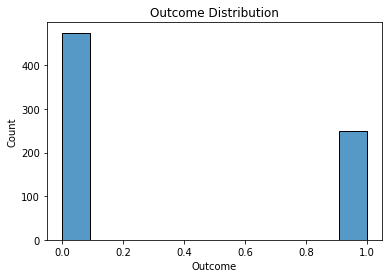

In [7]:
sns.histplot(x = diabetes_data.Outcome).set_title('Outcome Distribution');

There are more people without diabetes in this dataset than with it.

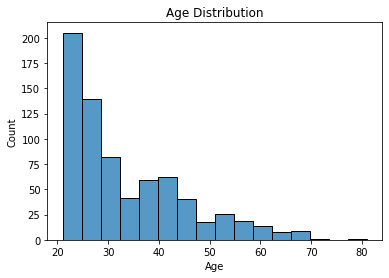

In [8]:
sns.histplot(x = diabetes_data.Age).set_title('Age Distribution');

The ages appear skewed pretty young if the median is 29 and this study only includes adults (above 21).

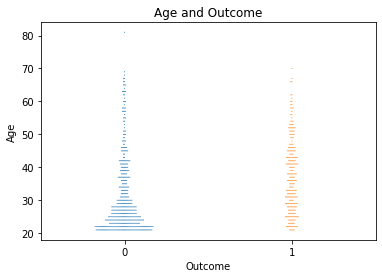

In [9]:
sns.swarmplot(x = diabetes_data.Outcome, 
              y = diabetes_data.Age, 
              s = 1).set_title('Age and Outcome');

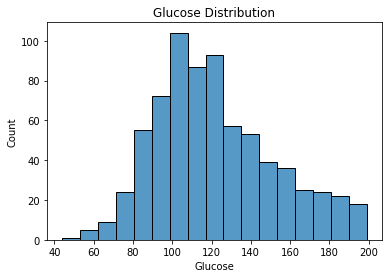

In [10]:
sns.histplot(x = diabetes_data.Glucose).set_title('Glucose Distribution');

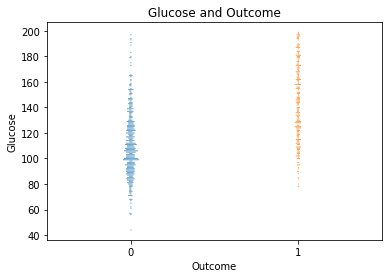

In [11]:
sns.swarmplot(x = diabetes_data.Outcome, 
              y = diabetes_data.Glucose, 
              s = 1).set_title('Glucose and Outcome');

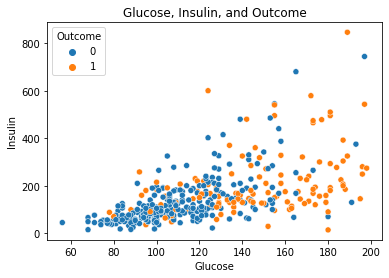

In [12]:
sns.scatterplot(x = diabetes_data.Glucose, 
                y = diabetes_data.Insulin, 
                hue = diabetes_data.Outcome).set_title('Glucose, Insulin, and Outcome');

Truly low glucose is less common than very high. It also appears that the higher the glucose, the more likely it is for the individual to have diabetes. I suspect this is one of the most predictive measures. It is also, however, clearly related to insulin.

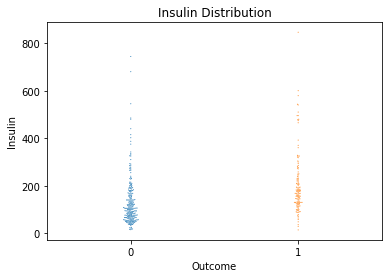

In [13]:
sns.swarmplot(x = diabetes_data.Outcome, 
              y = diabetes_data.Insulin, 
              s = 1).set_title('Insulin Distribution');

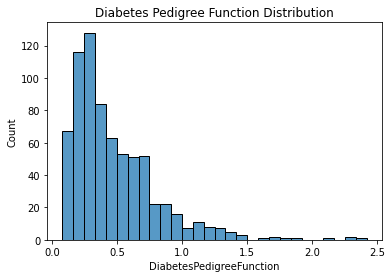

In [14]:
sns.histplot(x = diabetes_data.DiabetesPedigreeFunction).set_title('Diabetes Pedigree Function Distribution');

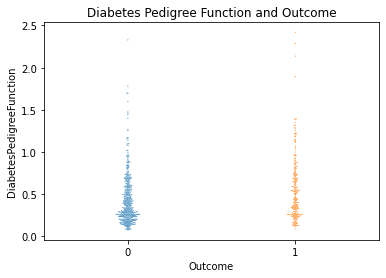

In [15]:
sns.swarmplot(x = diabetes_data.Outcome, 
              y = diabetes_data.DiabetesPedigreeFunction, 
              s = 1).set_title('Diabetes Pedigree Function and Outcome');

This appears to have less of an impact than I expected, although it is there.

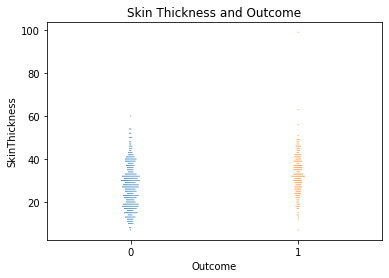

In [16]:
sns.swarmplot(x = diabetes_data.Outcome, 
              y = diabetes_data.SkinThickness, 
              s = 1).set_title('Skin Thickness and Outcome');

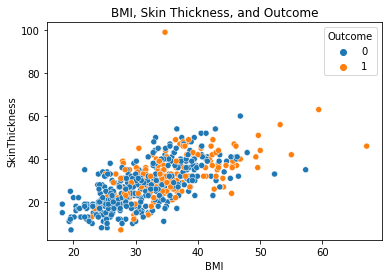

In [17]:
sns.scatterplot(x = diabetes_data.BMI, 
                y = diabetes_data.SkinThickness, 
                hue = diabetes_data.Outcome).set_title('BMI, Skin Thickness, and Outcome');

The skin thickness is also somewhat related to the outcome, although it is also clearly related to BMI, perhaps more than outcome.

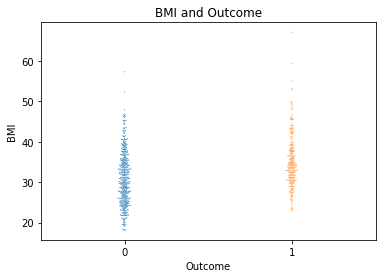

In [18]:
sns.swarmplot(x = diabetes_data.Outcome, 
              y = diabetes_data.BMI, 
              s = 1).set_title('BMI and Outcome');

This has a clear connection. Those with higher BMIs are more likely to be diabetic.

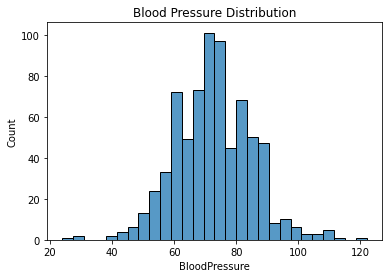

In [19]:
sns.histplot(x = diabetes_data.BloodPressure).set_title('Blood Pressure Distribution');

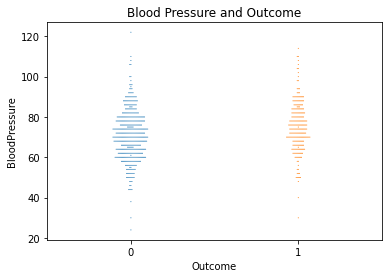

In [20]:
sns.swarmplot(x = diabetes_data.Outcome, 
              y = diabetes_data.BloodPressure, 
              s = 1).set_title('Blood Pressure and Outcome');

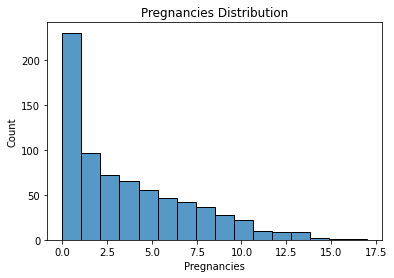

In [21]:
sns.histplot(x = diabetes_data.Pregnancies).set_title('Pregnancies Distribution');

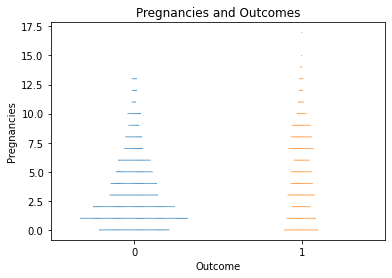

In [22]:
sns.swarmplot(x = diabetes_data.Outcome, 
              y = diabetes_data.Pregnancies, 
              s=1).set_title('Pregnancies and Outcomes');

In [23]:
diabetes_data.corr()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.134915,0.209668,0.095085,0.078984,0.012342,-0.025996,0.557066,0.224417
Glucose,0.134915,1.000000,0.223331,0.226590,0.581223,0.223276,0.136630,0.263560,0.488384
BloodPressure,0.209668,0.223331,1.000000,0.226072,0.098512,0.287403,-0.000075,0.324897,0.166703
SkinThickness,0.095085,0.226590,0.226072,1.000000,0.182199,0.647422,0.118636,0.161336,0.254874
Insulin,0.078984,0.581223,0.098512,0.182199,1.000000,0.226397,0.135906,0.217082,0.301429
BMI,0.012342,0.223276,0.287403,0.647422,0.226397,1.000000,0.154858,0.020835,0.299375
DiabetesPedigreeFunction,-0.025996,0.136630,-0.000075,0.118636,0.135906,0.154858,1.000000,0.023098,0.184947
Age,0.557066,0.263560,0.324897,0.161336,0.217082,0.020835,0.023098,1.000000,0.245741
Outcome,0.224417,0.488384,0.166703,0.254874,0.301429,0.299375,0.184947,0.245741,1.000000


Nothing is overwhelmingly decisive on its own. As suspected, glucose has the clearest connection. All together, however, they may form a better picture for predicting the outcome. 

# Classifier Model

I used Jeff Delaney's "10 Classifier Showdown in Scikit-Learn" as the basis for my own exploration of classifiers to find the one I think is most accurate. That is a wonderful notebook that I highly recommend. I am currently using a Gradient Boosting Classifier, but I'm continuing to learn and improve this notebook.

In [24]:
diabetes_data['PedigreeOverTime'] = diabetes_data.DiabetesPedigreeFunction * diabetes_data.Age

When checking the Permutation Importance as I tried out different models, I noticed that the DiabetesPedigreeFunction scored low. That was odd, since I knew that diabetes does have a genetic element. When I thought to do a bit of feature engineering, I decided to weigh the genetics more and more as someone gets older (multiplying the DiabetesPedigreeFunction by Age) and that was apparently useful, as it increased the accuracy a little. 

In [25]:
diabetes_data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,PedigreeOverTime
0,6,148,72,35.0,NaN,33.6,0.627,50,1,31.350
1,1,85,66,29.0,NaN,26.6,0.351,31,0,10.881
2,8,183,64,NaN,NaN,23.3,0.672,32,1,21.504
3,1,89,66,23.0,94.0,28.1,0.167,21,0,3.507
4,0,137,40,35.0,168.0,43.1,2.288,33,1,75.504


In [26]:
# Thank you to Dan Becker and Alexis Cook for the machine learning courses available on Kaggle.

from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier

features = ["Pregnancies", "Glucose", "BloodPressure", 
            "SkinThickness", "Insulin", 
            "DiabetesPedigreeFunction", 
            "BMI", "Age", 
            "PedigreeOverTime"]
X = diabetes_data[features]
y = diabetes_data.Outcome
X_train, X_valid, y_train, y_valid = train_test_split(X, y, 
                                                      random_state = 1, 
                                                      stratify = y)

imputer = SimpleImputer(strategy = 'median')
imputed_X_train = pd.DataFrame(imputer.fit_transform(X_train))
imputed_X_train.columns = X_train.columns

imputed_X_valid = pd.DataFrame(imputer.fit_transform(X_valid))
imputed_X_valid.columns = X_valid.columns

model = GradientBoostingClassifier(random_state = 1, 
                                   n_estimators = 50, 
                                   max_depth = 4)
model.fit(imputed_X_train, y_train)

prediction = model.predict(imputed_X_valid) 

score1 = accuracy_score(y_valid, prediction)
print("Accuracy: ", score1)

Accuracy:  0.7513812154696132


In [27]:
#Further gratitude to Dan Becker for the courses available on Kaggle.
import eli5
from eli5.sklearn import PermutationImportance

perm = PermutationImportance(model, 
                             random_state = 1).fit(imputed_X_valid, y_valid)
eli5.show_weights(perm, 
                  feature_names = imputed_X_valid.columns.tolist())

Weight,Feature
0.0873 ± 0.0515,Glucose
0.0309 ± 0.0301,BMI
0.0177 ± 0.0162,Insulin
0.0133 ± 0.0113,Age
0.0133 ± 0.0228,Pregnancies
0.0033 ± 0.0165,DiabetesPedigreeFunction
0.0022 ± 0.0429,PedigreeOverTime
-0.0011 ± 0.0108,BloodPressure
-0.0044 ± 0.0083,SkinThickness


# Conclusions

These 8 measures were likely included in the study for being known to have at least some relation to the likelihood of someone having or developing diabetes. The most predictive appeared to be glucose, which also had a strong relation to insulin. For insulin and skin thickness, there was missing data that had to be filled in, which I did using the median. Weighing the diabetes pedigree function over time led to good results, and there should still be room for the model to improve.

# Acknowledgements and Appreciation

A lot of my knowledge of machine learning has come from the machine learning courses made available here on Kaggle, although they did not look at this particular model. I am therefore grateful to Dan Becker and Alexis Cook. A big thank you to Jeff Delaney as well, as I expect that idea/notebook will help me in many future projects. Thank you to the entire Kaggle community for the information and inspiration made constantly available. 

UCI Machine Learning and the National Institute of Diabetes and Digestive and Kidney Diseases are responsible for the data. Thank you to them and to the people of Pima Indian heritage who supplied the data. 

After running into some problems, Jacopo Repossi was very generous in sharing knowledge, helping me to learn a lot and improve this work. Thank you. 

As this is my first official machine learning project, there is a lot that I'm unsure of and a lot for me to learn. Any advice and feedback is sincerely appreciated. 